In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

print("✓ Environment and visualization dependencies successfully loaded.")

✓ Environment and visualization dependencies successfully loaded.


In [21]:
file_path = "nhstalkingtherapies_month_mar_2026_activity_performance.csv"

df_raw = pd.read_csv(file_path)
print(f"Initial Ingestion Shape: {df_raw.shape}")

# Select and rename crucial features for footprint optimization
df_clean = df_raw[["ORG_NAME1", "MEASURE_NAME", "MEASURE_VALUE_SUPPRESSED"]].copy()
df_clean.columns = ["region", "measure", "value"]

# Programmatic Type Recasting: Cast text-bound suppression marks ('*') safely into NaNs, then drop them
df_clean["value"] = pd.to_numeric(df_clean["value"], errors="coerce")
df_clean = df_clean.dropna(subset=["value"])

print(f"Cleaned Dataset Shape (Post-Recasting): {df_clean.shape}")
df_clean.head()

Initial Ingestion Shape: (280581, 10)
Cleaned Dataset Shape (Post-Recasting): (68158, 3)


,region,measure,value
0,all SubICBs,Count_ReferralsReceived,163100.0
1,all SubICBs,Count_SelfReferrals,111830.0
2,all SubICBs,Count_GPReferrals,13461.0
3,all SubICBs,Count_HealthVisitorReferrals,433.0
4,all SubICBs,Count_OtherPrimaryCareReferrals,5840.0


In [22]:
# Define official operational regions established in your analytics tree
regions_of_interest = [
    'LONDON COMMISSIONING REGION', 'SOUTH WEST COMMISSIONING REGION',
    'SOUTH EAST COMMISSIONING REGION', 'MIDLANDS COMMISSIONING REGION',
    'EAST OF ENGLAND COMMISSIONING REGION', 'NORTH WEST COMMISSIONING REGION',
    'NORTH EAST AND YORKSHIRE COMMISSIONING REGION'
]

# Define structural metrics tracking the attrition funnel and non-attendance
target_measures = [
    'Count_ReferralsReceived', 'Count_FirstAssessment',
    'Count_SecondTreatment', 'Count_FinishedCourseTreatment',
    'Count_ApptsAttended', 'Count_ApptsDNA', 'Count_ApptsCancelledPatient'
]

# Filter down to structural regional metrics
df_filtered = df_clean[
    (df_clean["region"].isin(regions_of_interest)) & 
    (df_clean["measure"].isin(target_measures))
]

# Pivot data to transform measures from rows into clean feature columns
df_pivot = df_filtered.pivot_table(index="region", columns="measure", values="value").reset_index()

# Polish regional string attributes for professional reporting
df_pivot["Region_Clean"] = df_pivot["region"].str.replace(" COMMISSIONING REGION", "").str.title()
df_pivot["Region_Clean"] = df_pivot["Region_Clean"].replace("North East And Yorkshire", "North East & Yorkshire")

df_pivot.drop(columns=["region"], inplace=True)
df_pivot = df_pivot.rename(columns={"Region_Clean": "Region"})

df_pivot.head()

measure,Count_ApptsAttended,Count_ApptsCancelledPatient,Count_ApptsDNA,Count_FinishedCourseTreatment,Count_FirstAssessment,Count_ReferralsReceived,Count_SecondTreatment,Region
0,57550.0,7995.0,6320.0,6255.0,9790.0,17175.0,5340.0,East Of England
1,87995.0,12770.0,10425.0,9260.0,15110.0,26690.0,8920.0,London
2,99205.0,13680.0,10385.0,11000.0,17535.0,30160.0,10250.0,Midlands
3,81885.0,10935.0,9215.0,8235.0,15655.0,23750.0,8160.0,North East & Yorkshire
4,74210.0,10315.0,8765.0,7155.0,13760.0,25725.0,7250.0,North West


In [23]:
# 1. Compute Appointment Did Not Attend (DNA) Rate Coefficient
df_pivot['DNA_Rate_Percentage'] = (
    df_pivot['Count_ApptsDNA'] / (df_pivot['Count_ApptsAttended'] + df_pivot['Count_ApptsDNA']) * 100
).round(2)

# 2. Compute Early-Stage Referral-to-First-Assessment Drop-off Rate
df_pivot['Referral_to_Assessment_Dropoff_Pct'] = (
    100 - (df_pivot['Count_FirstAssessment'] / df_pivot['Count_ReferralsReceived'] * 100)
).round(2)

# 3. Compute Secondary-Stage Assessment-to-Second-Treatment Drop-off Rate
df_pivot['Assessment_to_SecondTx_Dropoff_Pct'] = (
    100 - (df_pivot['Count_SecondTreatment'] / df_pivot['Count_FirstAssessment'] * 100)
).round(2)

output_csv = "iapt_funnel_dropoff_matrix.csv"
df_pivot.to_csv(output_csv, index=False)

print(f"✓ Feature engineering completed. Output table matrix saved as: '{output_csv}'")
df_pivot[['Region', 'DNA_Rate_Percentage', 'Referral_to_Assessment_Dropoff_Pct', 'Assessment_to_SecondTx_Dropoff_Pct']]

✓ Feature engineering completed. Output table matrix saved as: 'iapt_funnel_dropoff_matrix.csv'


measure,Region,DNA_Rate_Percentage,Referral_to_Assessment_Dropoff_Pct,Assessment_to_SecondTx_Dropoff_Pct
0,East Of England,9.90,43.00,45.45
1,London,10.59,43.39,40.97
2,Midlands,9.48,41.86,41.55
3,North East & Yorkshire,10.12,34.08,47.88
4,North West,10.56,46.51,47.31
5,South East,9.49,39.79,31.75
6,South West,9.21,41.54,45.66


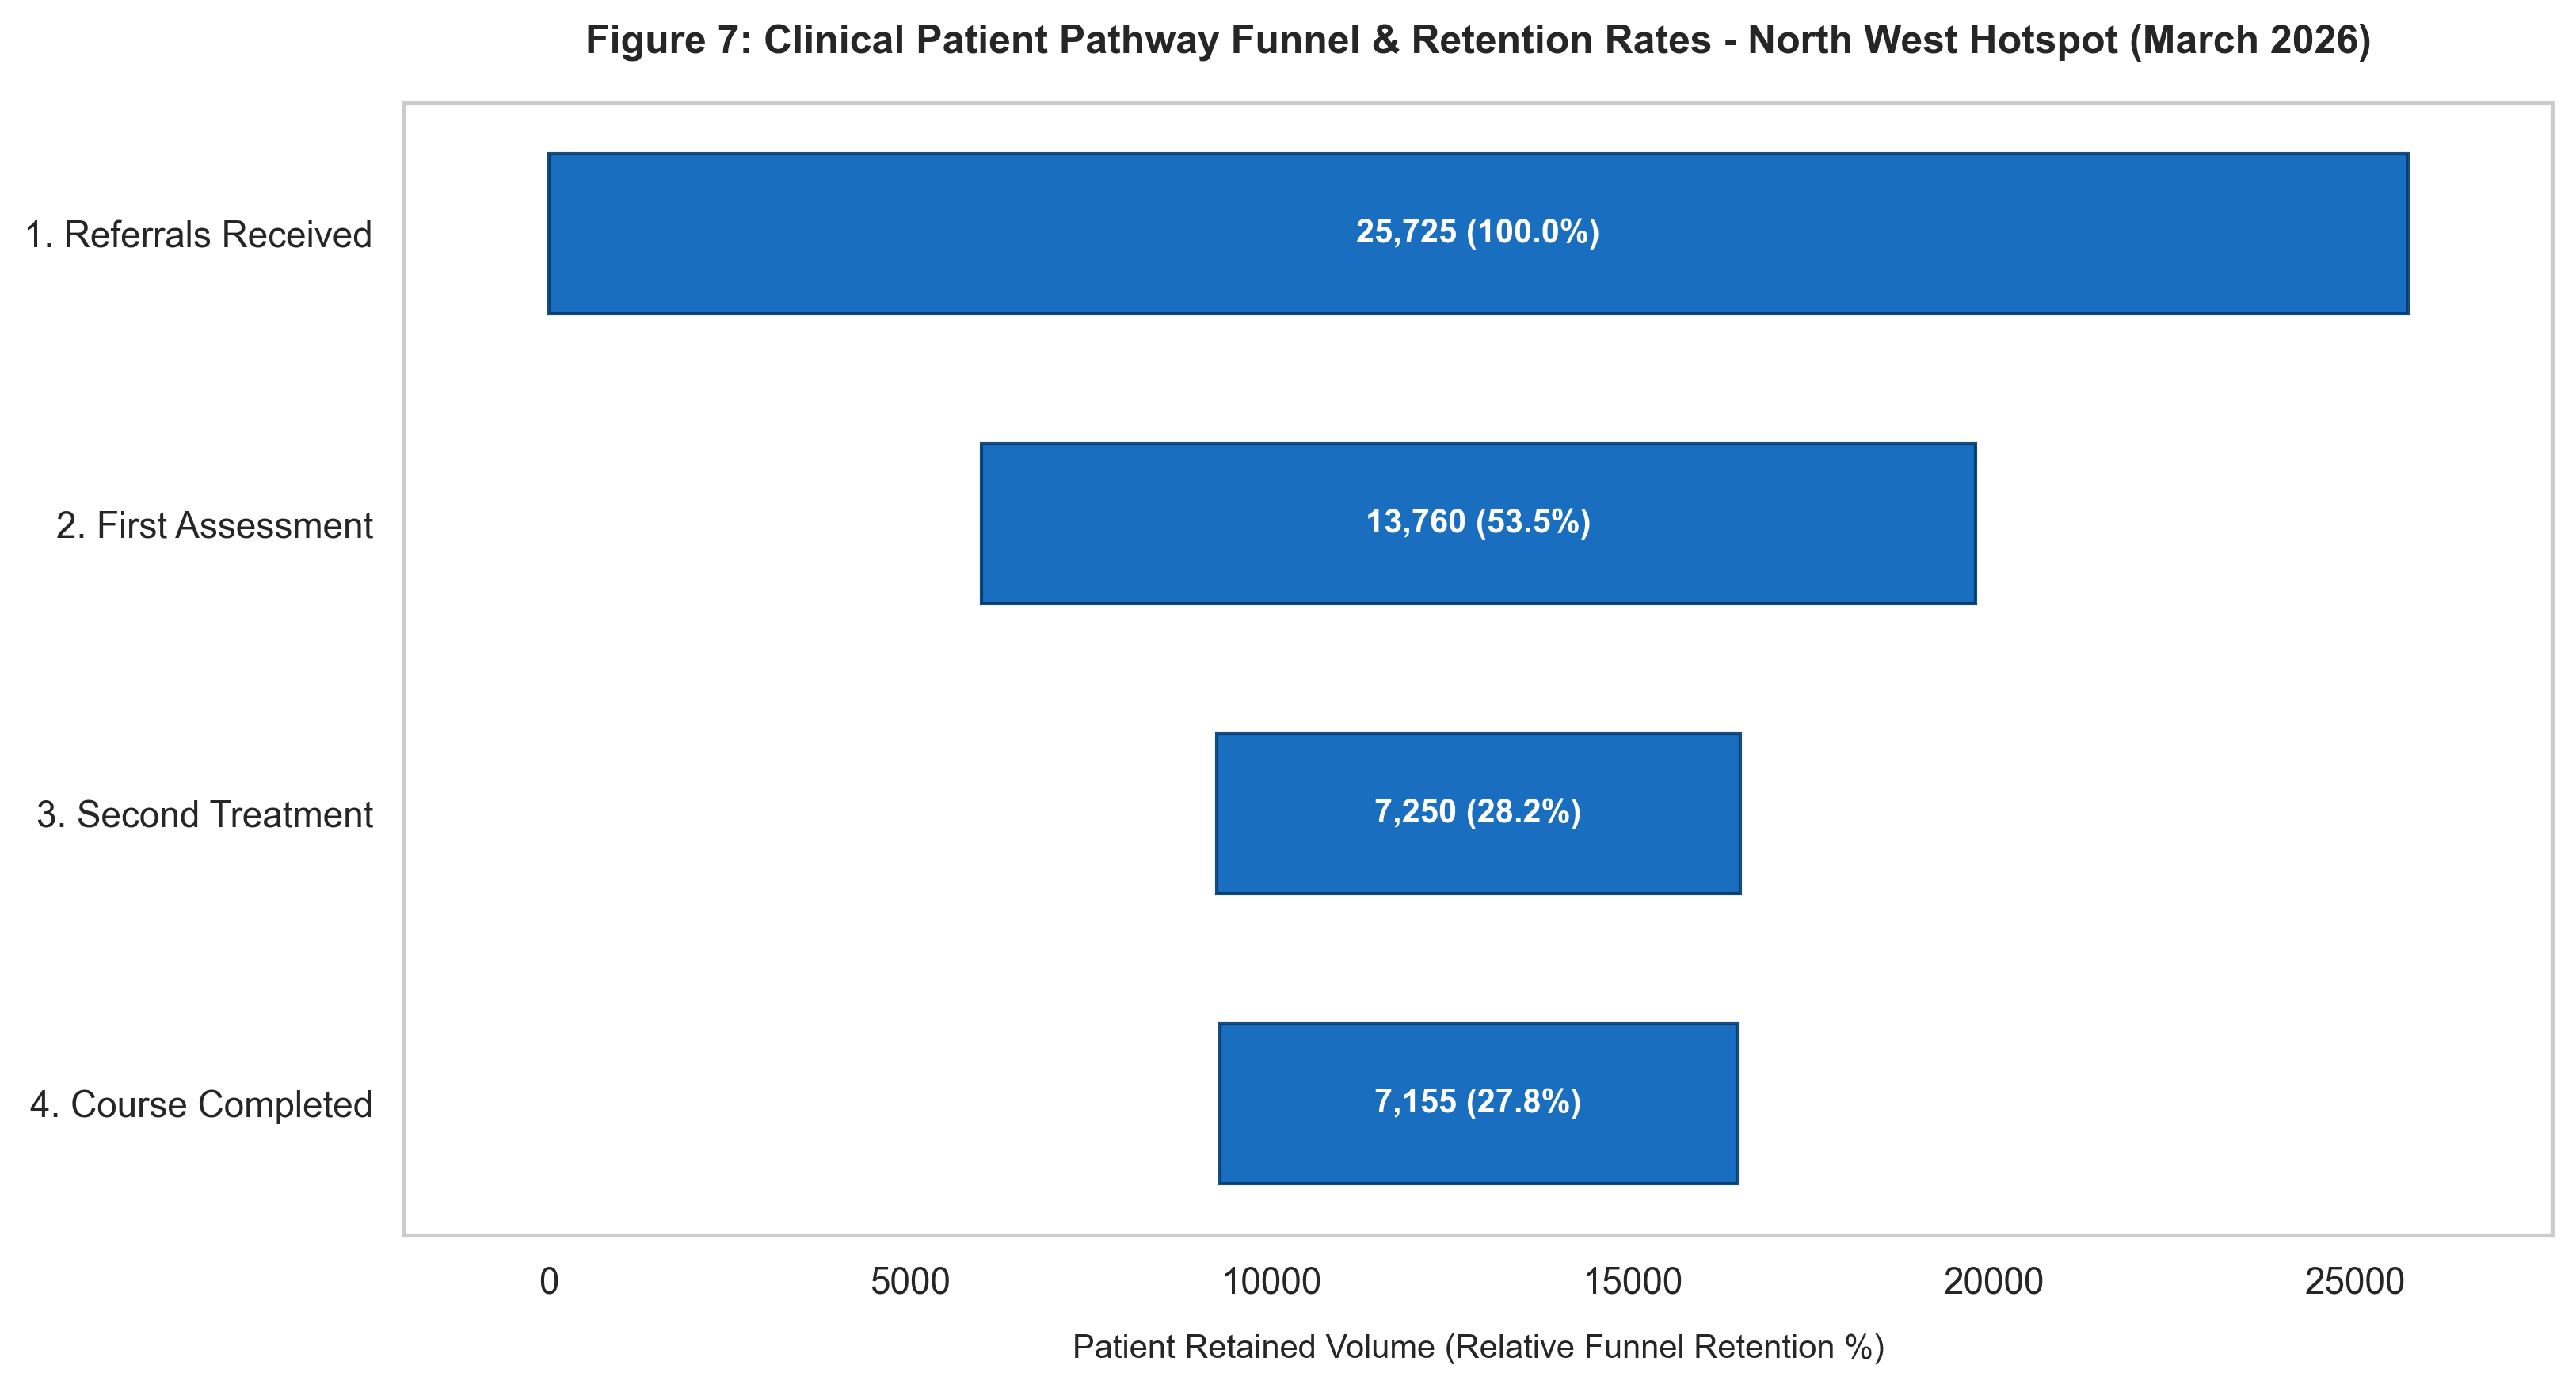

✓ Core visualization chart generated and exported as: 'iapt_treatment_funnel_chart.png'

  WEEK 3 ANA-2 PIPELINE EXECUTION COMPLETED SUCCESSFULLY


In [24]:
# Extract the series metrics for the North West Hotspot
nw_metrics = df_pivot[df_pivot['Region'] == 'North West'].iloc[0]

# Define funnel sequence coordinates
funnel_stages = [
    '1. Referrals Received',
    '2. First Assessment',
    '3. Second Treatment',
    '4. Course Completed'
]

funnel_volumes = [
    nw_metrics['Count_ReferralsReceived'],
    nw_metrics['Count_FirstAssessment'],
    nw_metrics['Count_SecondTreatment'],
    nw_metrics['Count_FinishedCourseTreatment']
]

# Configure horizontal centering offsets to form a funnel silhouette
max_funnel_volume = funnel_volumes[0]
horizontal_left_offsets = [(max_funnel_volume - vol) / 2 for vol in funnel_volumes]

# Construct visualization canvas
fig, ax = plt.subplots(figsize=(11, 6))

# Plot centered horizontal bars using standard NHS Blue (#005EB8)
bars = ax.barh(
    funnel_stages, funnel_volumes, 
    left=horizontal_left_offsets, 
    color='#005EB8', alpha=0.9, 
    edgecolor='#003A70', height=0.55
)

# Invert axis to ensure cascading top-down sequential data flow
ax.invert_yaxis()

# Overlay precise volume annotations and retention metrics onto the bars
for bar, vol in zip(bars, funnel_volumes):
    retention_pct = (vol / max_funnel_volume) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_y() + bar.get_height() / 2, 
        f"{int(vol):,} ({retention_pct:.1f}%)", 
        va='center', ha='center', color='white', fontweight='bold', fontsize=10
    )

# Formatting polish for executive delivery
ax.set_title('Figure 7: Clinical Patient Pathway Funnel & Retention Rates - North West Hotspot (March 2026)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Patient Retained Volume (Relative Funnel Retention %)', fontsize=10, labelpad=10)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xlim(-2000, max_funnel_volume + 2000)

plt.tight_layout()

# Save image file to the directory layout
output_png = "iapt_treatment_funnel_chart.png"
plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Core visualization chart generated and exported as: '{output_png}'")
print("\n=======================================================================")
print("  WEEK 3 ANA-2 PIPELINE EXECUTION COMPLETED SUCCESSFULLY")
print("=======================================================================")
